In [1]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [182]:
# Инициализация данных для обработки
import sqlite3

with sqlite3.connect("./data.db3") as con:
    with open('./sql/select_combinations.sql', 'rt') as f:
        sql_query = f.read()
        data = pd.read_sql(sql_query, con)

In [111]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73726 entries, 0 to 73725
Data columns (total 43 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   currency  73726 non-null  object 
 1   t1_dtime  73726 non-null  object 
 2   t1_open   73726 non-null  float64
 3   t1_high   73726 non-null  float64
 4   t1_low    73726 non-null  float64
 5   t1_close  73726 non-null  float64
 6   t1_ma5    73726 non-null  float64
 7   t1_ma10   73726 non-null  float64
 8   t2_dtime  73726 non-null  object 
 9   t2_open   73726 non-null  float64
 10  t2_high   73726 non-null  float64
 11  t2_low    73726 non-null  float64
 12  t2_close  73726 non-null  float64
 13  t2_ma5    73726 non-null  float64
 14  t2_ma10   73726 non-null  float64
 15  t3_dtime  73726 non-null  object 
 16  t3_open   73726 non-null  float64
 17  t3_high   73726 non-null  float64
 18  t3_low    73726 non-null  float64
 19  t3_close  73726 non-null  float64
 20  t3_ma5    73726 non-null  fl

In [150]:
data.head()

,currency,t1_dtime,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t2_dtime,t2_open,...,t3_close,t3_ma5,t3_ma10,t4_dtime,t4_open,t4_high,t4_low,t4_close,t4_ma5,t4_ma10
0,AUD,2001-02-05 12:00:00,0.5507,0.5531,0.5505,0.5516,0.551600,0.551600,2001-02-06 00:00:00,0.5519,...,0.5480,0.549833,0.549833,2001-02-07 00:00:00,0.5479,0.5507,0.5470,0.5494,0.549725,0.549725
1,AUD,2001-02-06 00:00:00,0.5519,0.5527,0.5480,0.5499,0.550750,0.550750,2001-02-06 12:00:00,0.5498,...,0.5494,0.549725,0.549725,2001-02-07 12:00:00,0.5494,0.5499,0.5444,0.5465,0.549080,0.549080
2,AUD,2001-02-06 12:00:00,0.5498,0.5512,0.5473,0.5480,0.549833,0.549833,2001-02-07 00:00:00,0.5479,...,0.5465,0.549080,0.549080,2001-02-08 00:00:00,0.5457,0.5464,0.5445,0.5459,0.547940,0.548550
3,AUD,2001-02-07 00:00:00,0.5479,0.5507,0.5470,0.5494,0.549725,0.549725,2001-02-07 12:00:00,0.5494,...,0.5459,0.547940,0.548550,2001-02-08 12:00:00,0.5459,0.5459,0.5415,0.5421,0.546380,0.547629
4,AUD,2001-02-07 12:00:00,0.5494,0.5499,0.5444,0.5465,0.549080,0.549080,2001-02-08 00:00:00,0.5457,...,0.5421,0.546380,0.547629,2001-02-09 00:00:00,0.5420,0.5430,0.5325,0.5368,0.544140,0.546275


In [74]:
# Проверка пропусков
data.isnull().sum().sum()

np.int64(0)

In [183]:
COMBINATION_LENGTH = 3
TARGET_CANDLE_PREFIX = f't{(COMBINATION_LENGTH + 1)}_'
LAST_CANDLE_PREFIX = f't{(COMBINATION_LENGTH)}_'

CLASS_LABEL_KEY = 'class'
OPEN_KEY_SUFFIX = 'open'
HIGH_KEY_SUFFIX = 'high'
LOW_KEY_SUFFIX = 'low'
CLOSE_KEY_SUFFIX = 'close'
MA5_KEY_SUFFIX = 'ma5'
MA10_KEY_SUFFIX = 'ma10'
NUMERIC_KEYS_SUFFIXES = (OPEN_KEY_SUFFIX, HIGH_KEY_SUFFIX, LOW_KEY_SUFFIX, CLOSE_KEY_SUFFIX, MA5_KEY_SUFFIX, MA10_KEY_SUFFIX)

DATE_KEY_SUFFIX = 'dtime'
DAY_OF_WEEK_SUFFIX = 'dweek'

IS_WHITE_KEY_SUFFIX = 'is_white'
PART_BODY_KEY_SUFFIX = 'part_body'
PART_HEAD_KEY_SUFFIX = 'head_body'
PART_TAIL_KEY_SUFFIX = 'tail_body'
POSITION_MA5_KEY_SUFFIX = 'ma5_position'
POSITION_MA10_KEY_SUFFIX = 'ma10_position'

In [184]:
# Разметка
target_candle_sizes = data[TARGET_CANDLE_PREFIX + HIGH_KEY_SUFFIX] - data[TARGET_CANDLE_PREFIX + LOW_KEY_SUFFIX]
target_candle_body_sizes = np.abs(data[TARGET_CANDLE_PREFIX + OPEN_KEY_SUFFIX] - data[TARGET_CANDLE_PREFIX + CLOSE_KEY_SUFFIX])

buy_class = ((data[TARGET_CANDLE_PREFIX + CLOSE_KEY_SUFFIX] > data[TARGET_CANDLE_PREFIX + OPEN_KEY_SUFFIX]) & 
             (data[TARGET_CANDLE_PREFIX + CLOSE_KEY_SUFFIX] > data[LAST_CANDLE_PREFIX + HIGH_KEY_SUFFIX]) & 
             (target_candle_body_sizes / target_candle_sizes > 0.5))

sell_class = ((data[TARGET_CANDLE_PREFIX + CLOSE_KEY_SUFFIX] < data[TARGET_CANDLE_PREFIX + OPEN_KEY_SUFFIX]) & 
              (data[TARGET_CANDLE_PREFIX + CLOSE_KEY_SUFFIX] < data[LAST_CANDLE_PREFIX + LOW_KEY_SUFFIX]) & 
              (target_candle_body_sizes / target_candle_sizes > 0.5))

data[CLASS_LABEL_KEY] = np.where(buy_class, 1, 
                                 0,)
                                #  np.where(sell_class, 2, 0))
data.value_counts(CLASS_LABEL_KEY)

class
0    62140
1    11586
Name: count, dtype: int64

In [153]:
import mplfinance as mpf

ITEM_INDEXES= range(1, COMBINATION_LENGTH + 1 + 1) # Количество элементов в комбинации + 1 целевой + 1 для невключительной границы

# Транспонирование одного наблюдения в последовательную комбинацию
def transpose_combination(combination_data: pd.Series) -> pd.DataFrame: 
    result = pd.DataFrame(columns=NUMERIC_KEYS_SUFFIXES)
    for i in ITEM_INDEXES:
        result.loc[pd.Timestamp(combination_data.loc[f't{i}_dtime'])] = combination_data.loc[[f't{i}_{key}' for key in NUMERIC_KEYS_SUFFIXES]].values.astype(np.float32)
    return result

def decode_class_label(combination_data: pd.Series) -> tuple[str, str]:
    cls = combination_data.get(CLASS_LABEL_KEY)
    if cls == 1:
        return ('BUY', 'green')
    elif cls == 2:
        return ('SELL', 'red')
    else:
        return ('PASS', 'grey')

# Визуализация комбинации
def print_combination(combination_data: pd.Series) -> None:
    transposed_combination = transpose_combination(combination_data)
    class_text, class_color = decode_class_label(combination_data)
    _, axes = mpf.plot(transposed_combination, type='candle', ylabel='', returnfig=True, title=f'Class: {class_text}')

    ax1 = axes[0]

    # Пометка целевой свечи
    ax1.scatter([COMBINATION_LENGTH], transposed_combination[-1:]['open'], color=class_color, s=100)
    
    # Графики MA до последней целевой свечи
    ax1.plot(range(COMBINATION_LENGTH), transposed_combination['ma5'][:-1], color='#FF9D68', label ='ma5')
    ax1.plot(range(COMBINATION_LENGTH), transposed_combination['ma10'][:-1], color='#FF7A92', label ='ma10')
    
    # График дней недели
    color = 'tab:blue'
    ax2 = ax1.twinx()
    ax2.set_ylabel('Days of week', color=color)
    ax2.plot(transposed_combination.index.day_of_week + 1, marker='o', ls='None', color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.set_ylim(0.8, 6.2)
    ax2.grid(False)

44484


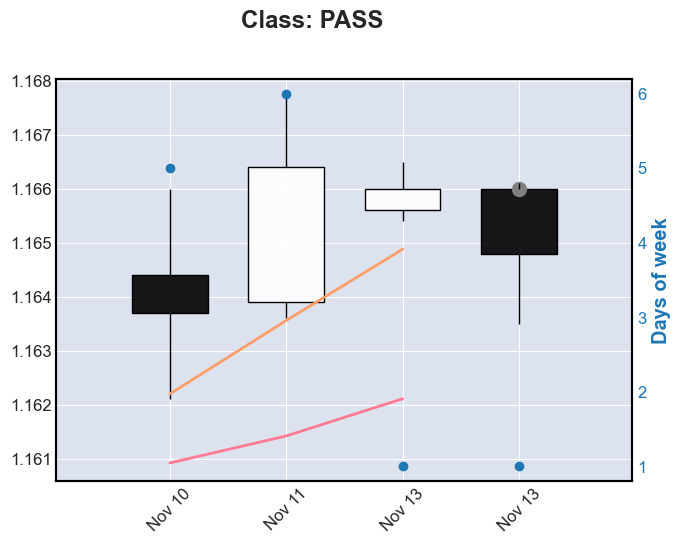

In [178]:
# Печать случайной комбинации
idx = np.random.choice(len(data))
print(idx)
print_combination(data.iloc[idx])

In [209]:
# Предобработка
from datetime import datetime

numeric_columns = [key for key in data.columns if any([key.endswith(suffix) for suffix in NUMERIC_KEYS_SUFFIXES]) and not key.startswith(TARGET_CANDLE_PREFIX)]

# Приведение ценовых показаетелей комбинации в масштаб [0,1]
data_min = data[numeric_columns].min(axis=1)
data_max = data[numeric_columns].max(axis=1)

processed_data = data.copy()
processed_data[numeric_columns] = processed_data[numeric_columns].sub(data_min, axis='rows').divide(data_max - data_min, axis='rows')

# Выделение дня недели
dtime_columns_fields = [(key, key.removesuffix(DATE_KEY_SUFFIX)) for key in data.columns if key.endswith(DATE_KEY_SUFFIX)]
for dtime_key, prefix in dtime_columns_fields:
    processed_data[prefix + DAY_OF_WEEK_SUFFIX] = processed_data[dtime_key].map(lambda t: datetime.fromisoformat(t).weekday())

# for i in (range(1, COMBINATION_LENGTH + 1)):
#     prefix = f't{i}_'
    
#     data_open = data[prefix + OPEN_KEY_SUFFIX]
#     data_high = data[prefix + HIGH_KEY_SUFFIX]
#     data_low = data[prefix + LOW_KEY_SUFFIX]
#     data_close = data[prefix + CLOSE_KEY_SUFFIX]
#     data_ma5 = data[prefix + MA5_KEY_SUFFIX]
#     data_ma10 = data[prefix + MA10_KEY_SUFFIX]

#     data_size = data_high - data_low

#     # Раскраска свечи
#     processed_data[prefix + IS_WHITE_KEY_SUFFIX] = (data_close > data_open).astype(np.byte)

#     # Дискретизация
#     def part_sampling(p):
#         return np.where(np.isnan(p), 0, np.floor(p * 10)).astype(np.byte)     
    
#     processed_data[prefix + PART_BODY_KEY_SUFFIX] = part_sampling(np.abs(data_close - data_open) / data_size)
#     processed_data[prefix + PART_HEAD_KEY_SUFFIX] = part_sampling((data_high - np.max([data_close, data_open], axis=0)) / data_size)
#     processed_data[prefix + PART_TAIL_KEY_SUFFIX] = part_sampling((np.min([data_close, data_open], axis=0) - data_low) / data_size)

#     # Относительное позиционирование
#     processed_data[prefix + POSITION_MA5_KEY_SUFFIX] = np.where(data_ma5 < data_low, 0,
#                                                                 np.where(data_ma5 < np.min([data_close, data_open], axis=0), 1,
#                                                                          np.where(data_ma5 < np.max([data_close, data_open], axis=0), 2,
#                                                                                   np.where(data_ma5 < data_high, 3, 4))))
    
#     processed_data[prefix + POSITION_MA10_KEY_SUFFIX] = np.where(data_ma10 < data_low, 0,
#                                                             np.where(data_ma10 < np.min([data_close, data_open], axis=0), 1,
#                                                                         np.where(data_ma10 < np.max([data_close, data_open], axis=0), 2,
#                                                                                 np.where(data_ma10 < data_high, 3, 4))))


In [210]:
# Удаление лишних столбцов
dtime_columns = [column[0] for column in dtime_columns_fields]
target_candle_columns = [column for column in processed_data.columns if column.startswith(TARGET_CANDLE_PREFIX)]
droped_columns = ['currency'] + dtime_columns + target_candle_columns 
# + numeric_columns

processed_data = processed_data.drop(droped_columns, axis=1)

In [211]:
# Только понедельники
processed_data = processed_data[processed_data['t2_dweek'] == 5]

In [212]:

# pd.set_option('display.max_rows', 100) 
# processed_data.iloc[idx]

processed_data.head()

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t2_open,t2_high,t2_low,t2_close,...,t3_open,t3_high,t3_low,t3_close,t3_ma5,t3_ma10,class,t1_dweek,t2_dweek,t3_dweek
8,0.236842,0.255061,0.072874,0.200405,0.668623,1.000000,0.291498,0.318826,0.000000,0.182186,...,0.300607,0.519231,0.163968,0.409919,0.349798,0.800709,0,4,5,1
17,0.013870,0.859917,0.000000,0.596394,0.349515,1.000000,0.582524,0.929265,0.374480,0.582524,...,0.624133,0.735090,0.485437,0.582524,0.341193,0.783634,0,4,5,0
28,0.432836,0.477612,0.000000,0.268657,0.438806,0.697015,0.253731,0.910448,0.029851,0.910448,...,0.567164,1.000000,0.567164,0.880597,0.522388,0.625373,0,4,5,0
38,0.731707,0.817073,0.402439,0.804878,0.668293,0.530488,0.804878,1.000000,0.634146,0.975610,...,0.597561,0.634146,0.000000,0.109756,0.673171,0.521951,0,4,5,0
48,0.391499,0.704698,0.324385,0.480984,0.366890,1.000000,0.503356,0.615213,0.000000,0.145414,...,0.190157,0.223714,0.000000,0.055928,0.217002,0.596197,0,4,5,0


In [148]:
processed_data.isnull().sum()

class               0
t1_dweek            0
t2_dweek            0
t3_dweek            0
t5_dweek            0
t6_dweek            0
t1_is_white         0
t1_part_body        0
t1_head_body        0
t1_tail_body        0
t1_ma5_position     0
t1_ma10_position    0
t2_is_white         0
t2_part_body        0
t2_head_body        0
t2_tail_body        0
t2_ma5_position     0
t2_ma10_position    0
t3_is_white         0
t3_part_body        0
t3_head_body        0
t3_tail_body        0
t3_ma5_position     0
t3_ma10_position    0
dtype: int64

In [213]:
# Моделирование
from sklearn.metrics import precision_score, mean_absolute_error
from sklearn.model_selection import train_test_split

# Разделение на множества данных
X_train, X_test, y_train, y_test = train_test_split(
    processed_data.drop([CLASS_LABEL_KEY], axis=1), processed_data[CLASS_LABEL_KEY], test_size=0.3, random_state=5, shuffle=True, stratify=processed_data[CLASS_LABEL_KEY]
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=5, stratify=y_test
)

print(f'Тренировочный набор: {y_train.value_counts()}')
print(f'Валидационный набор: {y_val.value_counts()}')
print(f'Тестовый набор: {y_test.value_counts()}')

Тренировочный набор: class
0    3705
1     976
Name: count, dtype: int64
Валидационный набор: class
0    794
1    209
Name: count, dtype: int64
Тестовый набор: class
0    794
1    210
Name: count, dtype: int64


In [ ]:
from catboost import CatBoostClassifier

classifier = CatBoostClassifier(n_estimators=1000, 
                                max_depth=10, 
                                learning_rate=0.05, 
                                thread_count=20, 
                                auto_class_weights='Balanced', 
                                leaf_estimation_iterations=3
                                )
                                # auto_class_weights='Balanced', loss_function='CrossEntropy')
classifier.fit(X_train, y_train)
y_train_pred = classifier.predict(X_train)
q_train = precision_score(y_true=y_train, y_pred=y_train_pred
                        )
                        #   , average=None)


print(q_train)

y_val_pred = classifier.predict(X_val)
q_val = precision_score(y_true=y_val, y_pred=y_val_pred
                        )
                        # , average=None)
print(q_val, y_val_pred.sum())

y_test_pred = classifier.predict(X_test)
q_test = precision_score(y_true=y_test, y_pred=y_test_pred
                        )
                        # , average=None)
print(q_test, y_test_pred.sum())

# for d in depth:
#     clf = CatBoostClassifier(n_estimators=n_trees, max_depth=d, logging_level="Silent")
#     clf.fit(X_train, y_train)
#     q_train = roc_auc_score(y_train, clf.predict_proba(X_train)[:, 1])
#     q_test = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
#     quals_cat_train.append(q_train)
#     quals_cat_test.append(q_test)

0:	learn: 0.6897931	total: 36.5ms	remaining: 36.5s
1:	learn: 0.6867290	total: 74.6ms	remaining: 37.2s
2:	learn: 0.6833635	total: 111ms	remaining: 36.9s
3:	learn: 0.6800842	total: 144ms	remaining: 35.8s
4:	learn: 0.6772399	total: 177ms	remaining: 35.3s
5:	learn: 0.6747464	total: 212ms	remaining: 35.1s
6:	learn: 0.6724627	total: 243ms	remaining: 34.4s
7:	learn: 0.6699028	total: 277ms	remaining: 34.3s
8:	learn: 0.6675953	total: 309ms	remaining: 34s
9:	learn: 0.6654116	total: 345ms	remaining: 34.1s
10:	learn: 0.6635069	total: 379ms	remaining: 34.1s
11:	learn: 0.6614957	total: 411ms	remaining: 33.8s
12:	learn: 0.6598487	total: 443ms	remaining: 33.6s
13:	learn: 0.6579608	total: 476ms	remaining: 33.5s
14:	learn: 0.6562641	total: 509ms	remaining: 33.4s
15:	learn: 0.6547477	total: 543ms	remaining: 33.4s
16:	learn: 0.6533120	total: 575ms	remaining: 33.3s
17:	learn: 0.6520397	total: 607ms	remaining: 33.1s
18:	learn: 0.6506912	total: 642ms	remaining: 33.2s
19:	learn: 0.6495660	total: 676ms	remaini

In [52]:
from catboost import CatBoostClassifier

def fit_classifier(X_train, y_train, **kwargs):
    clf = CatBoostClassifier(
        **kwargs,
        learning_rate=0.08, 
        auto_class_weights='Balanced', 
        leaf_estimation_iterations=3,
        logging_level="Silent"
        )
    clf.fit(X_train, y_train)
    return clf

# Кривая обучения
def train(X_train, y_train, X_val, y_val, **kwargs):
    clf = fit_classifier(X_train=X_train, y_train=y_train, **kwargs)

    y_train_pred = clf.predict(X_train)
    q_train = precision_score(y_true=y_train, y_pred=y_train_pred)

    y_val_pred = clf.predict(X_val)
    q_val = precision_score(y_true=y_val, y_pred=y_val_pred)

    print(f'Args: {kwargs}, Val qual: {q_val}, Val pred {y_val_pred.sum()}')

    return q_train, q_val

In [19]:
# Печать кривой обучения
def print_train_curve(ax1, title, xlabel, complexity, quals_train, quals_val):
    # Общая шкала аргумента
    ax1.set_xlabel(xlabel)
    ax1.set_title(title)

    # Совмещение графиков
    ax2 = ax1.twinx()

    color = 'tab:red'
    ax1.set_ylabel('Train error', color=color)
    ax1.plot(complexity, quals_train, color=color)
    ax1.tick_params(axis='y', labelcolor=color)

    color = 'tab:blue'
    ax2.set_ylabel('Val error', color=color)
    ax2.plot(complexity, quals_val, color=color)
    ax2.tick_params(axis='y', labelcolor=color)

Args: {'n_estimators': 600, 'max_depth': 6}, Val qual: 0.3157894736842105, Val pred 171
Args: {'n_estimators': 700, 'max_depth': 6}, Val qual: 0.3136094674556213, Val pred 169
Args: {'n_estimators': 800, 'max_depth': 6}, Val qual: 0.3202614379084967, Val pred 153
Args: {'n_estimators': 900, 'max_depth': 6}, Val qual: 0.302158273381295, Val pred 139
Args: {'n_estimators': 1000, 'max_depth': 6}, Val qual: 0.2867647058823529, Val pred 136
Args: {'n_estimators': 1100, 'max_depth': 6}, Val qual: 0.29365079365079366, Val pred 126
Args: {'n_estimators': 600, 'max_depth': 7}, Val qual: 0.2605633802816901, Val pred 142
Args: {'n_estimators': 700, 'max_depth': 7}, Val qual: 0.28225806451612906, Val pred 124
Args: {'n_estimators': 800, 'max_depth': 7}, Val qual: 0.25217391304347825, Val pred 115
Args: {'n_estimators': 900, 'max_depth': 7}, Val qual: 0.24299065420560748, Val pred 107
Args: {'n_estimators': 1000, 'max_depth': 7}, Val qual: 0.24742268041237114, Val pred 97
Args: {'n_estimators': 110

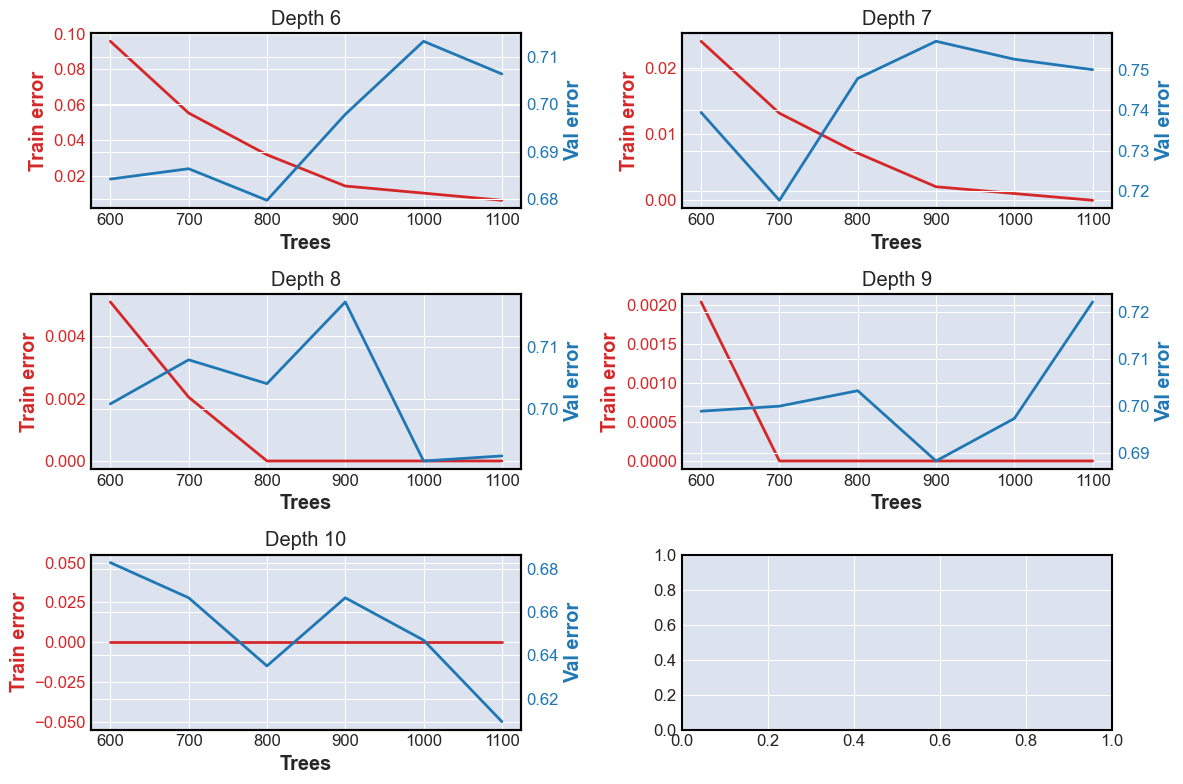

In [214]:
axes_columns_num = 2
# depth = range(8, 14)
# trees = range(800, 1500, 100)
depth = range(6, 11)
trees = range(600, 1200, 100)

fig, axes = plt.subplots(ncols=axes_columns_num, nrows=math.ceil(len(depth)/axes_columns_num), figsize=(12, 8))

for i, d in enumerate(depth):
    quals_train = []
    quals_val = []

    for t in trees:
        q_train, q_val = train(X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, n_estimators=t, max_depth=d)

        quals_train.append(1 - q_train)
        quals_val.append(1 - q_val)

    print_train_curve(axes[i//axes_columns_num][i%axes_columns_num], f'Depth {d}', 'Trees', trees, quals_train, quals_val)

fig.tight_layout()
plt.show()

In [215]:
clf = fit_classifier(X_train=X_train, y_train=y_train, n_estimators=800, max_depth=6)

y_val_pred = clf.predict(X_val)
q_val = precision_score(y_true=y_val, y_pred=y_val_pred)

print(q_val)

0.3202614379084967


In [216]:
y_test_pred = clf.predict(X_test)
q_test = precision_score(y_true=y_test, y_pred=y_test_pred)

print(q_test)

0.2236842105263158


In [66]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Так как в задаче не предполается тестовый набор праметры масштабирования выучиваются на всём датасете
scaler.fit(X_val)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
# X_val_scaled = scaler.transform(X_val)

X_val_scaled.describe()

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t2_open,t2_high,t2_low,t2_close,...,t1_dweek,t2_dweek,t3_dweek,t4_dweek,t5_dweek,t1_is_white,t2_is_white,t3_is_white,t4_is_white,t5_is_white
count,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,...,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000
mean,0.498589,0.700855,0.294127,0.501386,0.498600,0.497055,0.501228,0.690599,0.294409,0.500442,...,0.454924,0.451325,0.451451,0.451198,0.453712,0.504205,0.492359,0.494620,0.505561,0.500226
std,0.275231,0.249136,0.247768,0.235969,0.269390,0.374394,0.235404,0.231120,0.219799,0.221168,...,0.321795,0.320696,0.319857,0.318730,0.317901,0.500005,0.499964,0.499994,0.499992,0.500023
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.267977,0.503118,0.049096,0.311600,0.271017,0.117544,0.313266,0.514533,0.103316,0.326531,...,0.200000,0.200000,0.200000,0.200000,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.491667,0.727495,0.266300,0.499046,0.500000,0.498810,0.500000,0.709228,0.273608,0.500000,...,0.400000,0.400000,0.400000,0.400000,0.400000,1.000000,0.000000,0.000000,1.000000,1.000000
75%,0.731331,0.947791,0.489866,0.689018,0.726445,0.875609,0.687754,0.894159,0.463571,0.672492,...,0.800000,0.800000,0.800000,0.800000,0.800000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [132]:
y_val_pred.sum()

np.int64(655)

In [133]:
y_val.sum()

np.int64(1738)

In [54]:
103.45 - 90.9

12.549999999999997

In [37]:
(y_val * y_val_pred.squeeze()).count()

np.int64(11059)

In [29]:
y_val_pred

array([1, 0, 0, ..., 0, 0, 0], shape=(11059,))

In [61]:
y_val

3084     0
2220     0
66616    0
48177    0
53687    0
        ..
33032    0
22680    0
29680    1
21299    0
18407    0
Name: class, Length: 11059, dtype: int64

In [19]:
len(y_val)

11059

In [67]:
X_val

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t2_open,t2_high,t2_low,t2_close,...,t1_dweek,t2_dweek,t3_dweek,t4_dweek,t5_dweek,t1_is_white,t2_is_white,t3_is_white,t4_is_white,t5_is_white
3084,0.423529,1.000000,0.400000,0.623529,0.498824,0.309412,0.611765,0.929412,0.505882,0.552941,...,3,4,4,5,0,1,0,0,1,0
2220,0.000000,0.335570,0.000000,0.290828,0.519016,1.000000,0.302013,0.458613,0.100671,0.391499,...,0,0,1,1,2,1,1,1,1,1
66616,0.573034,0.685393,0.235955,0.505618,0.370787,0.379775,0.516854,1.000000,0.393258,0.797753,...,1,1,2,2,3,0,1,0,0,1
48177,0.092820,0.364273,0.000000,0.357268,0.143608,0.069527,0.355517,0.462347,0.327496,0.394046,...,1,2,2,3,3,1,1,1,1,1
53687,0.773131,0.887199,0.481622,0.570342,0.712294,1.000000,0.583016,0.633714,0.304183,0.468948,...,0,1,1,2,2,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33032,0.698630,0.808219,0.607306,0.698630,0.490411,0.000000,0.716895,0.936073,0.607306,0.908676,...,4,5,0,0,1,0,1,1,1,0
22680,0.824818,1.000000,0.700730,0.744526,0.702190,0.559854,0.729927,0.795620,0.445255,0.510949,...,2,2,3,3,4,0,0,0,1,1
29680,0.484848,0.787879,0.128788,0.765152,0.601515,0.848485,0.765152,1.000000,0.416667,0.446970,...,3,4,4,5,0,1,0,1,0,0
21299,0.523256,0.843023,0.517442,0.598837,0.641860,0.536047,0.604651,0.674419,0.505814,0.656977,...,1,1,2,2,3,1,1,0,0,0


In [68]:
X_val_scaled

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t2_open,t2_high,t2_low,t2_close,...,t1_dweek,t2_dweek,t3_dweek,t4_dweek,t5_dweek,t1_is_white,t2_is_white,t3_is_white,t4_is_white,t5_is_white
3084,0.423529,1.000000,0.407143,0.622811,0.498824,0.309412,0.611765,0.924610,0.515080,0.552941,...,0.6,0.8,0.8,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2220,0.000000,0.312855,0.000000,0.289474,0.519016,1.000000,0.302013,0.421784,0.102502,0.391499,...,0.0,0.0,0.2,0.2,0.4,1.0,1.0,1.0,1.0,1.0
66616,0.573034,0.674637,0.240169,0.504675,0.370787,0.379775,0.516854,1.000000,0.400409,0.797753,...,0.2,0.2,0.4,0.4,0.6,0.0,1.0,0.0,0.0,1.0
48177,0.092820,0.342539,0.000000,0.356041,0.143608,0.069527,0.355517,0.425772,0.333450,0.394046,...,0.2,0.4,0.4,0.6,0.6,1.0,1.0,1.0,1.0,1.0
53687,0.773131,0.883343,0.490223,0.569522,0.712294,1.000000,0.583016,0.608796,0.309713,0.468948,...,0.0,0.2,0.2,0.4,0.4,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33032,0.698630,0.801663,0.618151,0.698055,0.490411,0.000000,0.716895,0.931724,0.618348,0.908676,...,0.8,1.0,0.0,0.0,0.2,0.0,1.0,1.0,1.0,0.0
22680,0.824818,1.000000,0.713243,0.744038,0.702190,0.559854,0.729927,0.781717,0.453351,0.510949,...,0.4,0.4,0.6,0.6,0.8,0.0,0.0,0.0,1.0,1.0
29680,0.484848,0.780627,0.131088,0.764703,0.601515,0.848485,0.765152,1.000000,0.424242,0.446970,...,0.6,0.8,0.8,1.0,0.0,1.0,0.0,1.0,0.0,0.0
21299,0.523256,0.837657,0.526682,0.598072,0.641860,0.536047,0.604651,0.652270,0.515011,0.656977,...,0.2,0.2,0.4,0.4,0.6,1.0,1.0,0.0,0.0,0.0


In [113]:
X_val_scaled_with_pred = X_val_scaled.copy()
X_val_scaled_with_pred = pd.concat([X_val_scaled_with_pred, y_val], axis=1)
X_val_scaled_with_pred['class_pred'] = y_val_pred

In [117]:
y_val_pred.sum()

np.int64(1297)

In [ ]:
X_val_scaled_is_class_true = X_val_scaled_with_pred[X_val_scaled_with_pred['class'] == 1]
y_val_scaled_pred_class = X_val_scaled_is_class_true['class_pred']
X_val_scaled_is_class_true = X_val_scaled_is_class_true.drop(['class', 'class_pred'], axis=1)

In [103]:
X_val_scaled_is_class_true

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t2_open,t2_high,t2_low,t2_close,...,t1_dweek,t2_dweek,t3_dweek,t4_dweek,t5_dweek,t1_is_white,t2_is_white,t3_is_white,t4_is_white,t5_is_white
69999,0.928571,1.000000,0.575574,0.582538,0.722619,0.589881,0.589286,0.567703,0.187879,0.339286,...,0.4,0.4,0.6,0.6,0.8,0.0,0.0,0.0,1.0,0.0
36625,0.562500,0.676816,0.445312,0.561665,0.413636,0.170455,0.568182,1.000000,0.000000,0.142045,...,0.8,1.0,0.0,0.0,0.2,0.0,0.0,0.0,1.0,1.0
54612,0.285193,0.800102,0.279150,0.714993,0.287381,0.000000,0.722830,0.711765,0.550308,0.628009,...,0.8,0.8,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
68862,0.760563,0.810642,0.200704,0.421433,0.791549,0.402817,0.422535,0.638977,0.000000,0.647887,...,0.4,0.6,0.6,0.8,0.8,0.0,1.0,0.0,1.0,1.0
9113,0.103896,0.503053,0.000000,0.492540,0.262338,0.336364,0.519481,0.556145,0.185124,0.519481,...,0.2,0.2,0.4,0.4,0.6,1.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23181,0.627907,0.651262,0.248547,0.277694,0.655814,0.862791,0.302326,0.813716,0.000000,0.720930,...,0.2,0.4,0.4,0.6,0.6,0.0,1.0,1.0,0.0,1.0
41954,0.762675,0.921906,0.682963,0.848687,0.298813,0.000000,0.848975,1.000000,0.501952,0.638619,...,0.8,1.0,0.0,0.0,0.2,1.0,0.0,1.0,1.0,1.0
63804,0.576471,1.000000,0.000000,0.163112,0.416471,0.622353,0.164706,0.472269,0.071872,0.447059,...,0.2,0.4,0.4,0.6,0.6,0.0,1.0,1.0,1.0,1.0
48943,0.493274,0.712468,0.392537,0.559699,0.646637,0.761435,0.547085,0.554590,0.493110,0.488789,...,1.0,0.0,0.0,0.2,0.2,1.0,0.0,0.0,1.0,1.0


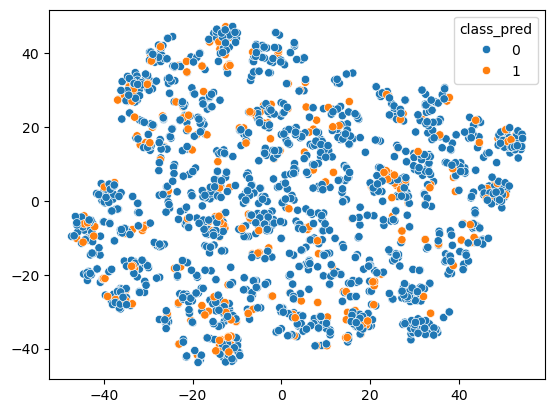

In [83]:
tsne = TSNE(n_components=2, random_state=10)

train_tsne = tsne.fit_transform(X_val_scaled_is_class_true)

g = sns.scatterplot(x=train_tsne[:,0], y=train_tsne[:,1], hue=y_val_scaled_pred_class)

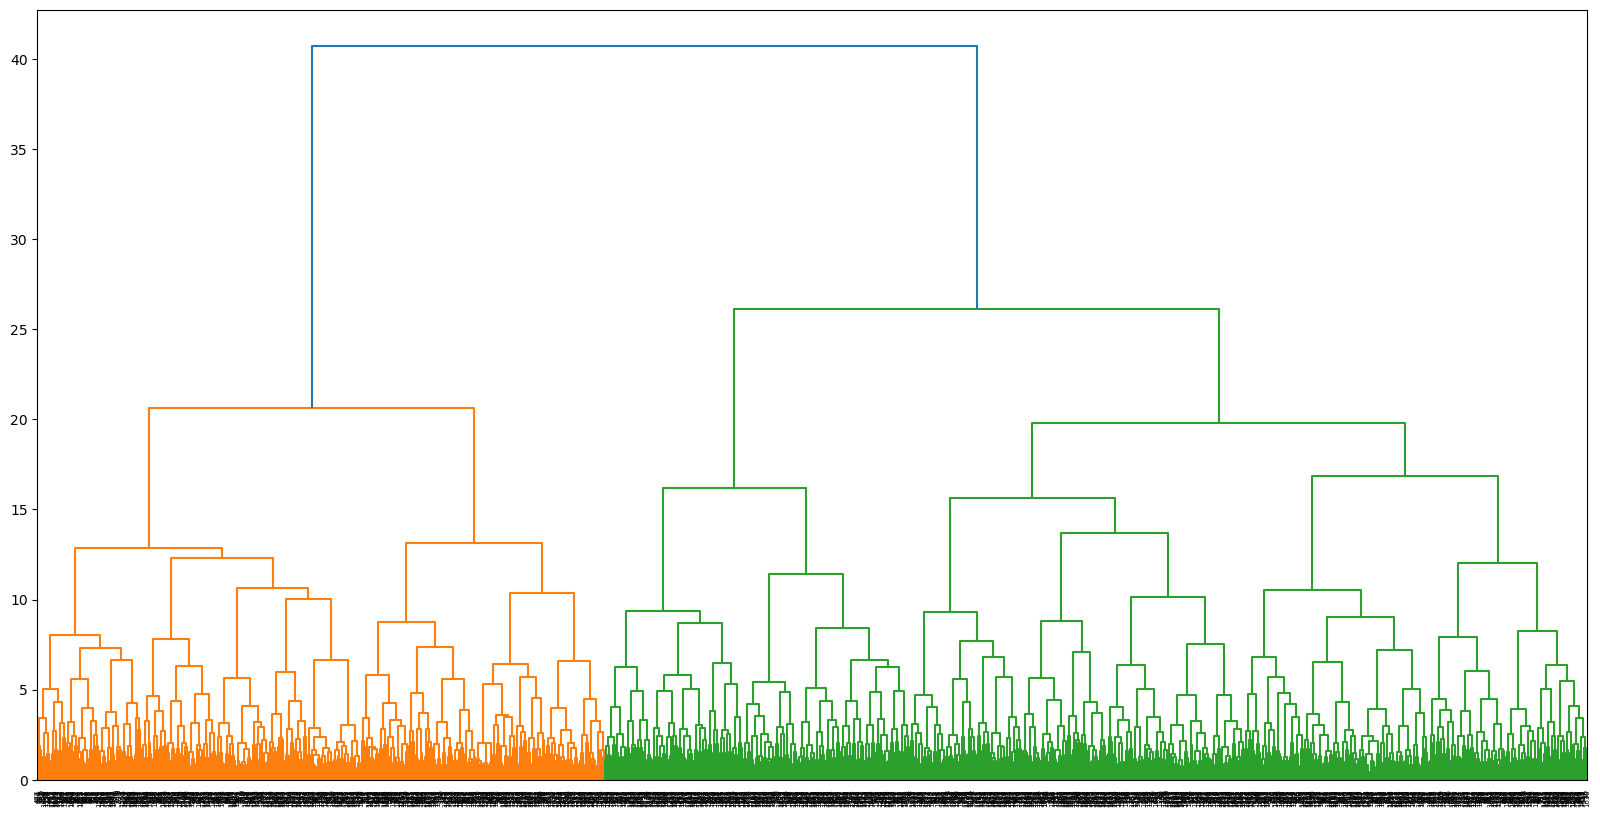

In [104]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(20,10))
linkage_ = linkage(X_val_scaled_is_class_true, method='ward')
dendrogram_ = dendrogram(linkage_)


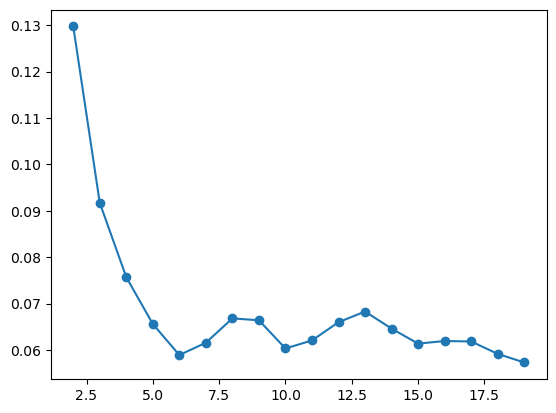

In [105]:
silhouette = []
clasters = range(2,20)
for i in clasters:
    agg = AgglomerativeClustering(n_clusters=i).fit(X_val_scaled_is_class_true)
    labels = agg.labels_
    score = silhouette_score(X_val_scaled_is_class_true, labels)
    silhouette.append(score)

plt.plot(clasters, silhouette, marker='o');

In [106]:
agg = AgglomerativeClustering(n_clusters=14).fit(X_val_scaled_is_class_true)
labels = agg.labels_

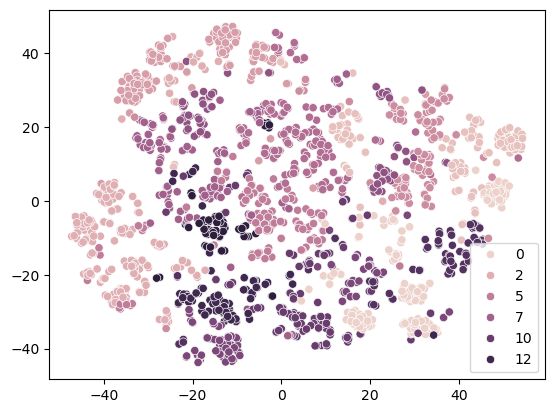

In [107]:
tsne = TSNE(n_components=2, random_state=10)

train_tsne = tsne.fit_transform(X_val_scaled_is_class_true)

g = sns.scatterplot(x=train_tsne[:,0], y=train_tsne[:,1], hue=labels)

In [108]:
X_val_scaled_is_class_true['labels'] = labels
X_val_scaled_is_class_true['class_pred'] = y_val_scaled_pred_class

X_val_scaled_is_class_true

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t2_open,t2_high,t2_low,t2_close,...,t3_dweek,t4_dweek,t5_dweek,t1_is_white,t2_is_white,t3_is_white,t4_is_white,t5_is_white,labels,class_pred
69999,0.928571,1.000000,0.575574,0.582538,0.722619,0.589881,0.589286,0.567703,0.187879,0.339286,...,0.6,0.6,0.8,0.0,0.0,0.0,1.0,0.0,0,0
36625,0.562500,0.676816,0.445312,0.561665,0.413636,0.170455,0.568182,1.000000,0.000000,0.142045,...,0.0,0.0,0.2,0.0,0.0,0.0,1.0,1.0,10,0
54612,0.285193,0.800102,0.279150,0.714993,0.287381,0.000000,0.722830,0.711765,0.550308,0.628009,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,7,0
68862,0.760563,0.810642,0.200704,0.421433,0.791549,0.402817,0.422535,0.638977,0.000000,0.647887,...,0.6,0.8,0.8,0.0,1.0,0.0,1.0,1.0,9,0
9113,0.103896,0.503053,0.000000,0.492540,0.262338,0.336364,0.519481,0.556145,0.185124,0.519481,...,0.4,0.4,0.6,1.0,0.0,1.0,1.0,0.0,7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23181,0.627907,0.651262,0.248547,0.277694,0.655814,0.862791,0.302326,0.813716,0.000000,0.720930,...,0.4,0.6,0.6,0.0,1.0,1.0,0.0,1.0,3,0
41954,0.762675,0.921906,0.682963,0.848687,0.298813,0.000000,0.848975,1.000000,0.501952,0.638619,...,0.0,0.0,0.2,1.0,0.0,1.0,1.0,1.0,7,0
63804,0.576471,1.000000,0.000000,0.163112,0.416471,0.622353,0.164706,0.472269,0.071872,0.447059,...,0.4,0.6,0.6,0.0,1.0,1.0,1.0,1.0,5,0
48943,0.493274,0.712468,0.392537,0.559699,0.646637,0.761435,0.547085,0.554590,0.493110,0.488789,...,0.0,0.2,0.2,1.0,0.0,0.0,1.0,1.0,10,0


In [109]:
X_val_scaled_is_class_true[['class_pred','labels']].groupby('labels').agg(['count', 'sum', 'mean'])

class_pred              
            count sum      mean
labels                         
0             163  17  0.104294
1             144  22  0.152778
2             208  32  0.153846
3             153  32  0.209150
4             129  26  0.201550
5             125  18  0.144000
6             155  26  0.167742
7             126  22  0.174603
8              96  18  0.187500
9              92  18  0.195652
10            117  21  0.179487
11             83  17  0.204819
12             85  12  0.141176
13             62  13  0.209677

In [112]:
X_val_scaled_is_class_true['class_pred'].agg(['count', 'sum', 'mean'])

count    1738.00000
sum       294.00000
mean        0.16916
Name: class_pred, dtype: float64